In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global font: larger, bold Times New Roman
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.serif': ['Times New Roman']
})

# Load overhead benchmark CSVs (search recursively)
csv_files = sorted(Path('../Benchmark/overhead_results').rglob('bench_overhead_*.csv'))
if not csv_files:
    raise FileNotFoundError('No overhead benchmark CSV files found.')
frames = []
for fp in csv_files:
    df = pd.read_csv(fp)
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
data['size'] = data['size'].astype(int)
data


,approach,query,size,mean_ms,std_ms
0,escrow,contact_valid,100,7.446096,1.960526
1,baseline,contact_valid,100,6.902521,0.928283
2,escrow,photo_transform,100,28.760341,1.397086
3,baseline,photo_transform,100,30.272763,1.953740
4,escrow,contact_valid,1000,15.302121,1.353049
5,baseline,contact_valid,1000,16.196963,3.202466
6,escrow,photo_transform,1000,33.528800,3.525221
7,baseline,photo_transform,1000,34.872221,3.633856
8,escrow,contact_valid,10000,112.631708,7.532788
9,baseline,contact_valid,10000,111.058617,10.695118


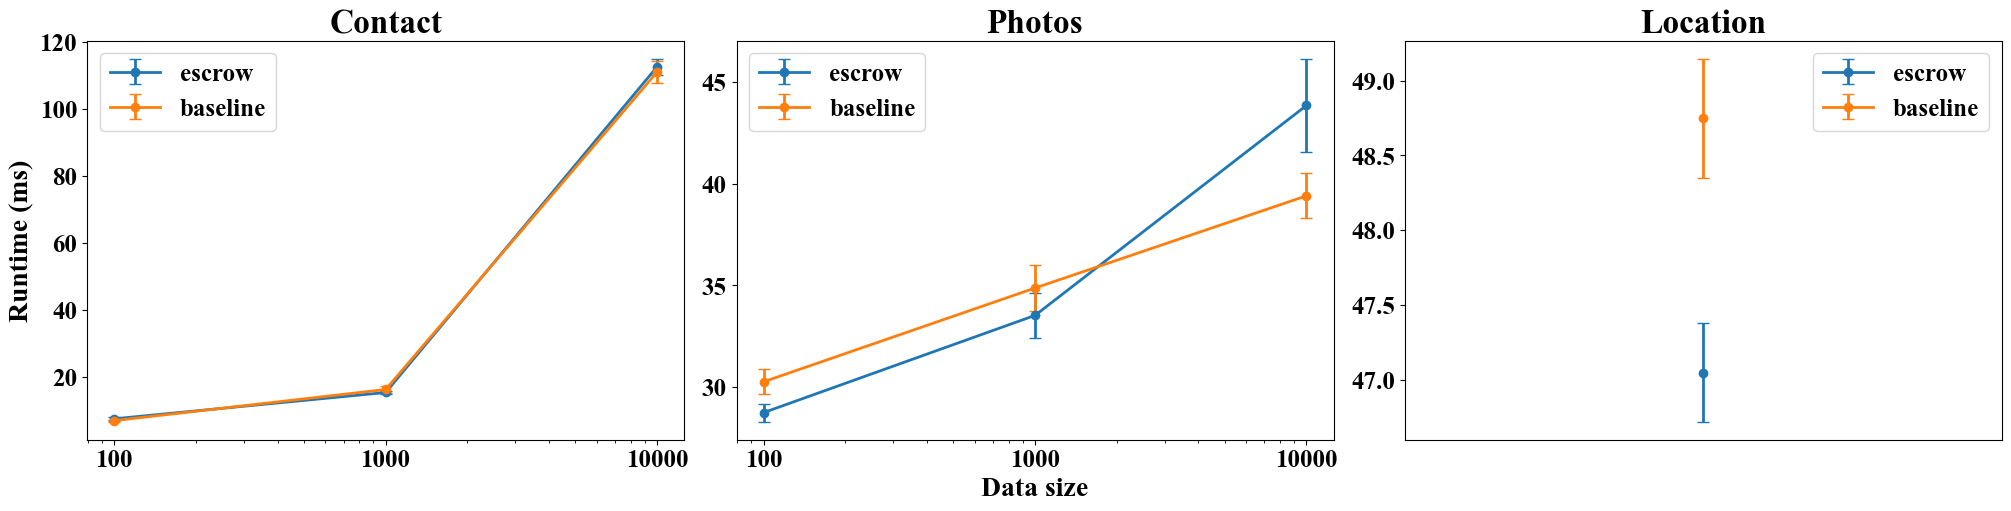

In [6]:
# Plotting
queries = {
    'contact_valid': 'Contact',
    'photo_transform': 'Photos',
    'location_weather': 'Location'
}
approaches = data['approach'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False, constrained_layout=True)

for ax, (q, title) in zip(axes, queries.items()):
    is_loc_plot = (title == 'Location')

    for approach in approaches:
        d = data[(data['query'] == q) & (data['approach'] == approach)].sort_values('size')
        if is_loc_plot:
            d = d[d['size'] == 0]
        if d.empty:
            continue
        ax.errorbar(d['size'], d['mean_ms'], yerr=d['std_ms']/np.sqrt(10), marker='o', capsize=4, label=approach, linewidth=2)
    ax.set_title(title)
    # ax.set_yscale('log')
    if is_loc_plot:
        ax.set_xticks([])
    else:
        ax.set_xscale('log')
        ax.set_xticks(sorted(d['size'].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    if title == 'Photos':
        ax.set_xlabel('Data size')
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.legend(fontsize=18)
axes[0].set_ylabel('Runtime (ms)', fontweight='bold')
# plt.tight_layout()  # not needed with constrained_layout
fig_name = f"figures/overhead/overhead.pdf"
plt.savefig(fig_name, bbox_inches='tight')
plt.show()
plt.close()